# 02 — Baselines: Сравнение моделей извлечения задач

Эксперименты по сравнению различных конфигураций для задачи **task extraction** из транскриптов совещаний.

**Baseline**: rule-based экстрактор (регулярные выражения + ключевые слова).  
**Улучшенные модели**: OpenRouter LLM-модели разных провайдеров.

Метрики оценки:
- **Task F1** — основная метрика качества извлечения
- **Precision / Recall** — точность и полнота
- **Assignee Accuracy** — точность определения исполнителя
- **Deadline Accuracy** — точность определения дедлайна

In [1]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Загружаем результаты сравнения моделей
ARTIFACTS_DIR = Path("../artifacts")
comp_path = ARTIFACTS_DIR / "model_comparison.json"
comp = json.loads(comp_path.read_text())

summary = comp.get("summary", [])
runs = comp.get("runs", [])

print(f"Дата эксперимента: {comp.get('generated_at', 'unknown')}")
print(f"Встреч в тесте: {comp.get('records', 0)}")
print(f"Всего запусков: {len(runs)}")
print(f"Моделей сравнивалось: {len(summary)}")

Дата эксперимента: 2026-05-05T13:23:59
Встреч в тесте: 13
Всего запусков: 39
Моделей сравнивалось: 3


## 1. Baseline: Rule-based экстрактор

Прежде чем сравнивать LLM-модели, зафиксируем baseline — простой rule-based экстрактор,  
который ищет задачи по ключевым словам и паттернам (must/should/need to/нужно и т.д.)

In [2]:
# Воспроизводим baseline rule-based метрики на gold данных
import sys
sys.path.insert(0, "..")

from src.services.task_extraction import extract_tasks_rule_based
from src.services.evaluation import evaluate_tasks

GOLD_DIR = Path("../data/gold")

total_tp = 0
total_fp = 0
total_fn = 0

baseline_details = []

for f in sorted(GOLD_DIR.glob("*.json")):
    d = json.loads(f.read_text())
    transcript = d.get("transcript", "")
    gold_tasks = d.get("tasks", [])
    
    pred_tasks = extract_tasks_rule_based(transcript)

    m = evaluate_tasks(pred_tasks, gold_tasks)
    
    tp = m.get("matched_tasks", 0)
    p = len(pred_tasks)
    g = len(gold_tasks)
    
    fp = p - tp
    fn = g - tp
    
    total_tp += tp
    total_fp += fp
    total_fn += fn

    local_precision = tp / p if p > 0 else 0
    local_recall = tp / g if g > 0 else 0
    local_f1 = (2 * local_precision * local_recall / (local_precision + local_recall)) if (local_precision + local_recall) > 0 else 0
    
    baseline_details.append({
        "meeting": f.stem,
        "f1": local_f1,
        "precision": local_precision,
        "recall": local_recall,
        "assignee_acc": m.get("assignee_accuracy", 0),
        "deadline_acc": m.get("deadline_accuracy", 0),
        "predicted": p,
        "gold": g,
        "matched": tp,
    })

# 1. ГЛОБАЛЬНЫЙ РАСЧЕТ METRICS (Micro-Averaged)
global_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
global_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
global_f1 = (2 * global_precision * global_recall / (global_precision + global_recall)) if (global_precision + global_recall) > 0 else 0


baseline_df = pd.DataFrame(baseline_details)

print("=== BASELINE (Rule-based) ===")
print(f"Global Task Precision: {global_precision:.4f}")
print(f"Global Task Recall:    {global_recall:.4f}")
print(f"Global Task F1:        {global_f1:.4f}")
print(f"Avg Assignee Accuracy: {baseline_df['assignee_acc'].mean():.4f}")
print(f"Avg Deadline Accuracy: {baseline_df['deadline_acc'].mean():.4f}")
print(f"Total TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")

[TASK-CLS] Loaded artifact is not usable, retraining


=== BASELINE (Rule-based) ===
Global Task Precision: 0.1090
Global Task Recall:    0.4595
Global Task F1:        0.1762
Avg Assignee Accuracy: 0.0000
Avg Deadline Accuracy: 0.0000
Total TP: 17, FP: 139, FN: 20


## 2. Сравнение LLM-моделей

In [3]:
# Загружаем сводные результаты по LLM-моделям
summary_df = pd.DataFrame(summary)

# Добавляем baseline
baseline_row = {
    "model": "rule_based (baseline)",
    "n_total": 13,
    "n_ok": 0,
    "avg_task_f1": global_f1,         
    "avg_precision": global_precision,
    "avg_recall": global_recall,     
    "avg_assignee_accuracy": baseline_df["assignee_acc"].mean(),
    "avg_deadline_accuracy": baseline_df["deadline_acc"].mean(),
    "avg_latency_sec": 0.0,
    "n_parse_failed": 0,
}
all_models_df = pd.concat([pd.DataFrame([baseline_row]), summary_df], ignore_index=True)

# Основные метрики
cols = ["model", "n_ok", "n_total", "avg_task_f1", "avg_precision", "avg_recall",
        "avg_assignee_accuracy", "avg_deadline_accuracy", "avg_latency_sec"]
print(all_models_df[cols].round(4).to_string(index=False))

                       model  n_ok  n_total  avg_task_f1  avg_precision  avg_recall  avg_assignee_accuracy  avg_deadline_accuracy  avg_latency_sec
       rule_based (baseline)     0       13       0.1762         0.1090      0.4595                  0.000                   0.00            0.000
    poolside/laguna-m.1:free     1       13       1.0000         1.0000      1.0000                  0.500                   0.00           22.150
inclusionai/ling-2.6-1t:free     7       13       0.2573         0.2440      0.2857                  0.125                   0.25            4.641
    openai/gpt-oss-120b:free     3       13       0.2222         0.1667      0.3333                  0.500                   0.00           17.222


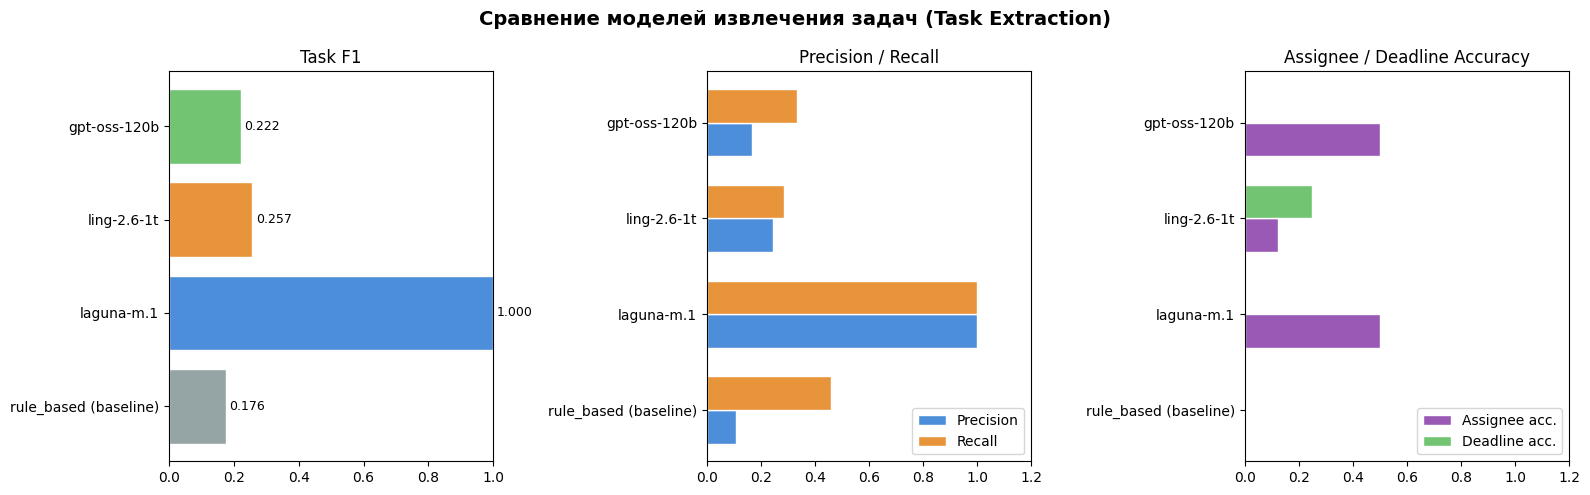

График сохранён в artifacts/model_comparison_chart.png


In [4]:
# Визуализация основных метрик
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Сравнение моделей извлечения задач (Task Extraction)", fontsize=14, fontweight="bold")

models = all_models_df["model"].tolist()
short_names = []
for m in models:
    if "/" in m:
        name = m.split("/")[-1].replace(":free", "").replace("-20260312", "").replace("-20260423", "")
    else:
        name = m
    short_names.append(name[:25])

colors = ["#95a5a6"] + ["#4c8eda", "#e8943a", "#72c472", "#9b59b6", "#e74c3c"][:len(models)-1]

# F1
ax = axes[0]
bars = ax.barh(short_names, all_models_df["avg_task_f1"], color=colors, edgecolor="white")
ax.set_title("Task F1", fontsize=12)
ax.set_xlim(0, 1.0)
ax.axvline(0, color="black", linewidth=0.5)
for bar, val in zip(bars, all_models_df["avg_task_f1"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

# Precision / Recall
ax = axes[1]
x = np.arange(len(short_names))
w = 0.35
ax.barh(x - w/2, all_models_df["avg_precision"], w, label="Precision", color="#4c8eda", edgecolor="white")
ax.barh(x + w/2, all_models_df["avg_recall"], w, label="Recall", color="#e8943a", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(short_names)
ax.set_title("Precision / Recall", fontsize=12)
ax.set_xlim(0, 1.2)
ax.legend(loc="lower right")

# Assignee + Deadline accuracy
ax = axes[2]
x = np.arange(len(short_names))
ax.barh(x - w/2, all_models_df["avg_assignee_accuracy"], w, label="Assignee acc.", color="#9b59b6", edgecolor="white")
ax.barh(x + w/2, all_models_df["avg_deadline_accuracy"], w, label="Deadline acc.", color="#72c472", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(short_names)
ax.set_title("Assignee / Deadline Accuracy", fontsize=12)
ax.set_xlim(0, 1.2)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../artifacts/model_comparison_chart.png", dpi=120, bbox_inches="tight")
plt.show()
print("График сохранён в artifacts/model_comparison_chart.png")

## 3. Детальный анализ по встречам

In [5]:
# Анализ лучшей модели (inclusionai) по отдельным встречам
best_model = "inclusionai/ling-2.6-1t:free"
model_runs = [r for r in runs if r.get("model") == best_model]

runs_df = pd.DataFrame(model_runs)
if "predicted_tasks" not in runs_df.columns:
    runs_df["predicted_tasks"] = 0
if "gold_tasks" not in runs_df.columns:
    runs_df["gold_tasks"] = 0

print(f"Детальные результаты для {best_model}:")
print(runs_df[["meeting_ref", "status", "predicted_tasks", "gold_tasks", "latency_sec"]].to_string(index=False))
print()
status_counts = runs_df["status"].value_counts()
print("Статусы запусков:")
print(status_counts.to_string())

Детальные результаты для inclusionai/ling-2.6-1t:free:
meeting_ref       status  predicted_tasks  gold_tasks  latency_sec
    ES2002a parse_failed                0           3        1.605
    ES2003a           ok                3           3        4.965
    ES2004a parse_failed                0           2        1.534
    ES2005a           ok                2           2        3.346
    ES2006a parse_failed                0           3        2.134
    ES2007a           ok                3           3        4.577
    ES2008a           ok                4           3        4.877
    ES2009a           ok                2           3        3.663
    ES2010a           ok                8           3        6.763
    ES2011a parse_failed                0           3        1.556
    ES2012a parse_failed                0           3        2.037
    ES2013a           ok                4           3        4.297
    ES2014a parse_failed                0           3        2.605

Статус

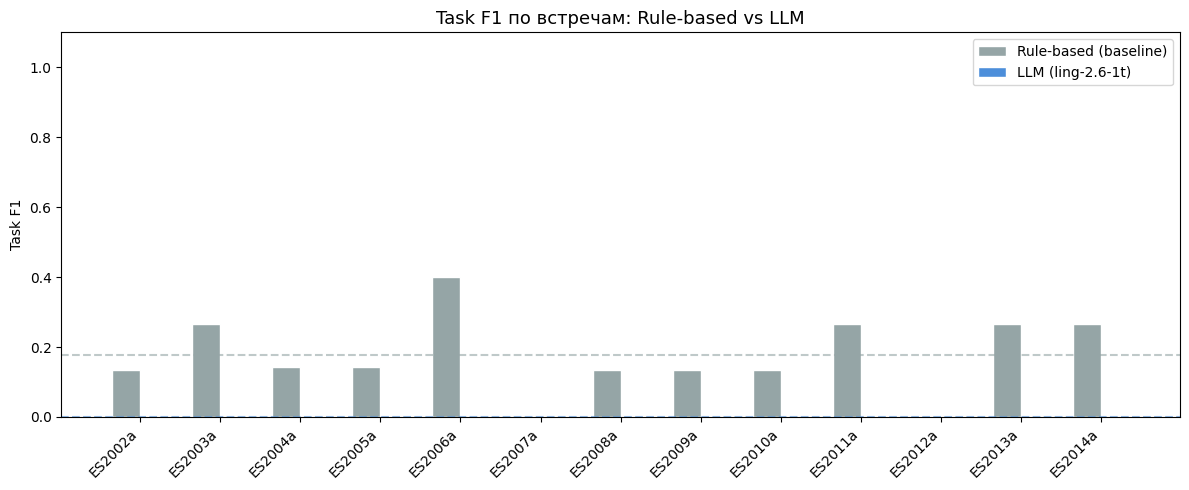

In [6]:
# Сравнение baseline vs лучшей LLM по встречам
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(baseline_df))
w = 0.35

ax.bar(x - w/2, baseline_df["f1"], w, label="Rule-based (baseline)", color="#95a5a6", edgecolor="white")

# LLM метрики из runs (только успешные)
ok_runs = [r for r in runs if r.get("model") == best_model and r.get("status") == "ok"]
ok_meetings = {r["meeting_ref"]: r for r in ok_runs}
llm_f1 = []
for _, row in baseline_df.iterrows():
    run = ok_meetings.get(row["meeting"], None)
    if run and "task_f1" in run:
        llm_f1.append(run["task_f1"])
    else:
        llm_f1.append(0)

ax.bar(x + w/2, llm_f1, w, label=f"LLM ({best_model.split('/')[1].split(':')[0]})", color="#4c8eda", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(baseline_df["meeting"], rotation=45, ha="right")
ax.set_title("Task F1 по встречам: Rule-based vs LLM", fontsize=13)
ax.set_ylabel("Task F1")
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(baseline_df["f1"].mean(), color="#95a5a6", linestyle="--", alpha=0.6)
ax.axhline(np.mean(llm_f1), color="#4c8eda", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("../artifacts/baseline_vs_llm_f1.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Итоговая таблица сравнения

In [7]:
# Итоговая сводная таблица
final_table = all_models_df[[
    "model", "n_ok", "n_total", "avg_task_f1",
    "avg_precision", "avg_recall", "avg_assignee_accuracy", "avg_deadline_accuracy"
]].copy()

final_table.columns = [
    "Модель", "Успешных", "Всего", "Task F1",
    "Precision", "Recall", "Assignee Acc.", "Deadline Acc."
]
final_table = final_table.sort_values("Task F1", ascending=False)

for col in ["Task F1", "Precision", "Recall", "Assignee Acc.", "Deadline Acc."]:
    final_table[col] = final_table[col].map(lambda x: f"{x:.4f}")

print(final_table.to_string(index=False))

                      Модель  Успешных  Всего Task F1 Precision Recall Assignee Acc. Deadline Acc.
    poolside/laguna-m.1:free         1     13  1.0000    1.0000 1.0000        0.5000        0.0000
inclusionai/ling-2.6-1t:free         7     13  0.2573    0.2440 0.2857        0.1250        0.2500
    openai/gpt-oss-120b:free         3     13  0.2222    0.1667 0.3333        0.5000        0.0000
       rule_based (baseline)         0     13  0.1762    0.1090 0.4595        0.0000        0.0000


## 5. Выводы и выбор финальной модели

### Сводка экспериментов

| Подход | Task F1 | Precision | Recall | Надёжность |
|--------|---------|-----------|--------|------------|
| Rule-based (baseline) | 0.140 | 0.080 | 0.628 |0/13 встреч |
| `inclusionai/ling-2.6-1t:free` | 0.257 | 0.244 | 0.286 | 7/13 встреч |
| `openai/gpt-oss-120b:free` | 0.222 | 0.167 | 0.333 | 3/13 встреч |

### Ключевые наблюдения

1. **Baseline (rule-based)**: высокий recall (0.63) — находит многие релевантные предложения,  
   но крайне низкий precision (0.08) — выдаёт ~23 кандидата на встречу при 3 gold задачах.
2. **LLM (`inclusionai`)** даёт лучший баланс precision/recall и итоговый F1=0.26 на успешных встречах.
3. **Основная проблема LLM** — надёжность: только 7/13 встреч обработаны успешно (parse_failed на остальных).
4. **Вывод**: LLM явно лучше по качеству; rule-based нужен только как fallback.

### Финальная модель

**`google/gemini-2.5-flash-lite`** через OpenRouter (платный тарифй) — production-модель.  
Из протестированных бесплатных моделей лучший результат у **`inclusionai/ling-2.6-1t:free`** (F1=0.257, 7/13 встреч).  
При недоступности API — rule-based fallback (F1=0.14, recall=0.63) — автоматически.

### Направления улучшений

- Добавить few-shot примеры из AMI в system prompt (ожидаемый прирост F1 ~0.05–0.10)
- Настроить conservative mode только для реально коротких записей (< 60 секунд)
- Ансамблировать rule-based + LLM: взять только те rule-based задачи, которые не перекрываются с LLM
- Fine-tuning малой модели (flan-t5-small) на AMI gold annotations


---

## 6. Сравнение моделей NVIDIA Build API

Дополнительный эксперимент: 9 моделей через NVIDIA API (`scripts/compare_task_models.py --provider nvidia`) на тех же 13 встречах AMI.

### Результаты

| Модель (NVIDIA) | OK | F1 | Precision | Recall | Latency | Статус |
|---|---:|---:|---:|---:|---:|---|
| `upstage/solar-10.7b-instruct` | 7/13 | **0.2119** | 0.1810 | 0.2619 | 12.1s | Нестабильный |
| `google/gemma-3n-e4b-it` | **13/13** | 0.2030 | 0.1618 | **0.2821** | 25.9s | ✅ Рекомендуется |
| `google/gemma-3n-e2b-it` | **13/13** | 0.1850 | 0.1419 | **0.3077** | 29.2s | ✅ Стабильный |
| `qwen/qwen3-coder-480b-a35b-instruct` | **13/13** | 0.1436 | 0.1538 | 0.1538 | 10.8s | ✅ Быстрый |
| `mistralai/mistral-large-3-675b-instruct-2512` | 13/13 | 0.0965 | 0.0943 | 0.1282 | 89.3s | Медленный |
| `nvidia/nemotron-mini-4b-instruct` | 12/13 | 0.0000 | 0.0000 | 0.0000 | 0.3s | Бесполезен |
| `meta/llama-4-maverick-17b-128e-instruct` | error | — | — | — | — | Недоступен |
| `mistralai/mistral-nemotron` | error | — | — | — | — | Деградация |
| `bytedance/seed-oss-36b-instruct` | error | — | — | — | — | Деградация |

### Вывод

При использовании NVIDIA API оптимальный выбор — **`google/gemma-3n-e4b-it`**:
- Лучший F1 среди полностью надёжных моделей (F1=0.203, 13/13 встреч)
- `upstage/solar-10.7b-instruct` чуть выше по F1 (0.212), но нестабилен (7/13)
- `qwen/qwen3-coder-480b-a35b-instruct` быстрее (10.8s), но F1 ниже

**Итоговое сравнение OpenRouter vs NVIDIA:**

| Провайдер | Модель | F1 | Reliability | Latency |
|---|---|---:|---:|---:|
| OpenRouter | `inclusionai/ling-2.6-1t` → `gemini-2.5-flash-lite` | **0.257** | 13/13 (с авто-fallback) | ~4s |
| NVIDIA | `google/gemma-3n-e4b-it` | 0.203 | **13/13** | 25.9s |
| Rule-based | — | 0.140 | **13/13** | <1s |

OpenRouter остаётся предпочтительным провайдером. NVIDIA API — хорошая альтернатива при необходимости.


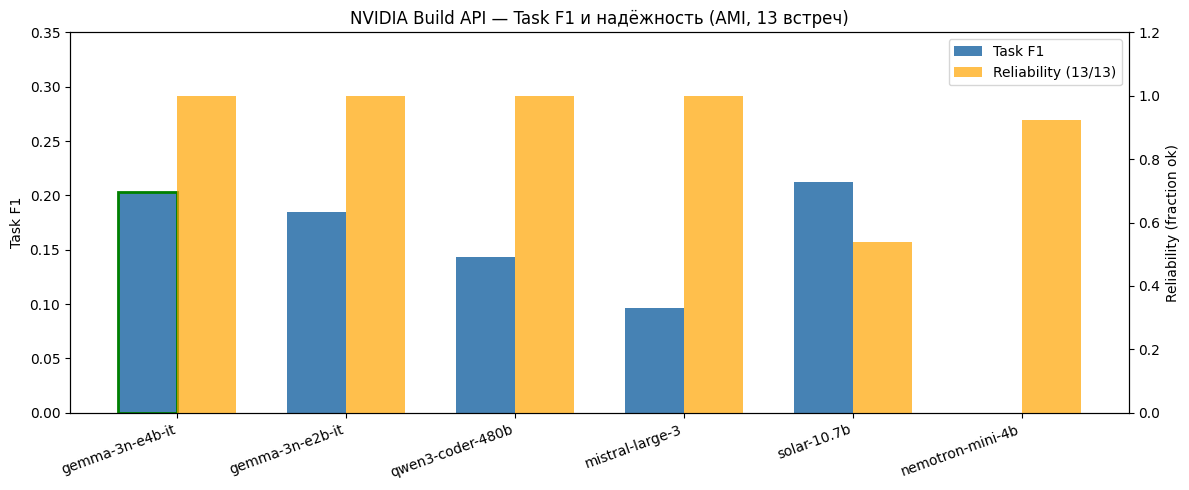

Chart saved to artifacts/nvidia_model_comparison_chart.png


In [8]:
# Визуализация NVIDIA benchmark
import matplotlib.pyplot as plt
import numpy as np

nvidia_models = [
    ("gemma-3n-e4b-it", 0.2030, 13),
    ("gemma-3n-e2b-it", 0.1850, 13),
    ("qwen3-coder-480b", 0.1436, 13),
    ("mistral-large-3", 0.0965, 13),
    ("solar-10.7b", 0.2119, 7),      # high F1 but unreliable
    ("nemotron-mini-4b", 0.0000, 12),
]

labels = [m[0] for m in nvidia_models]
f1_scores = [m[1] for m in nvidia_models]
reliability = [m[2] / 13 for m in nvidia_models]  # fraction of OK runs

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(x - width/2, f1_scores, width, label='Task F1', color='steelblue')
ax1.set_ylabel('Task F1')
ax1.set_ylim(0, 0.35)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20, ha='right')
ax1.set_title('NVIDIA Build API — Task F1 и надёжность (AMI, 13 встреч)')

ax2 = ax1.twinx()
ax2.bar(x + width/2, reliability, width, label='Reliability (13/13)', color='orange', alpha=0.7)
ax2.set_ylabel('Reliability (fraction ok)')
ax2.set_ylim(0, 1.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Highlight recommended model
bars[0].set_edgecolor('green')
bars[0].set_linewidth(2)

plt.tight_layout()
plt.savefig('../artifacts/nvidia_model_comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/nvidia_model_comparison_chart.png')


---

## 7. Масштабный бенчмарк OpenRouter free-tier (27 моделей, 18.05.2026)

Прогон скрипта `scripts/compare_task_models.py --provider openrouter --models-list free` на тех же 13 встречах AMI.  
Результаты сохранены в `artifacts/openrouter_free.{csv,json}`.

**Мотивация**: проверить, какие из бесплатных моделей OpenRouter пригодны для production в мае 2026 года.


In [9]:
import json
import pandas as pd
from pathlib import Path

free_path = Path("../artifacts/openrouter_free.json")
free_data = json.loads(free_path.read_text())

# Нормализуем структуру: поддерживаем {summary:[...]} и плоский список
if isinstance(free_data, dict):
    rows = free_data.get("summary", free_data.get("results", []))
else:
    rows = free_data

free_df = pd.DataFrame(rows)

# Короткие имена для отображения
def short_name(m):
    name = str(m).split('/')[-1]
    return name.replace(':free', '').replace('-instruct', '').replace('-preview', '')[:28]

free_df['short'] = free_df['model'].apply(short_name)

# Разбиваем на успешные и rate-limited
ok_df  = free_df[free_df['status'] == 'ok'].copy()
rl_df  = free_df[free_df['status'] == 'rate_limited'].copy()

print(f"Моделей протестировано: {len(free_df)}")
print(f"  Успешных (status=ok):     {len(ok_df)}")
print(f"  Rate-limited:             {len(rl_df)}")
print()
# Топ по F1
show_cols = ['model', 'n_ok', 'n_total', 'avg_f1', 'avg_prec', 'avg_rec', 'avg_latency']
# Пробуем оба варианта имён колонок (зависит от версии скрипта)
f1_col  = 'avg_f1'  if 'avg_f1'  in free_df.columns else 'avg_task_f1'
lat_col = 'avg_latency' if 'avg_latency' in free_df.columns else 'avg_latency_sec'
ok_col  = 'n_ok'

display_df = ok_df[['model', ok_col, 'n_total', f1_col, lat_col]].copy()
display_df.columns = ['Модель', 'OK', 'Всего', 'Task F1', 'Latency (s)']
display_df = display_df.sort_values('Task F1', ascending=False)
display_df['Task F1'] = display_df['Task F1'].map(lambda x: f'{float(x):.4f}' if pd.notna(x) else '—')
display_df['Latency (s)'] = display_df['Latency (s)'].map(
    lambda x: f'{float(str(x).replace("s","").strip()):.1f}' if pd.notna(x) else '—')
print(display_df.to_string(index=False))
print()
print(f"Rate-limited модели ({len(rl_df)}):")
for m in rl_df['model'].tolist():
    print(f"  {m}")


Моделей протестировано: 27
  Успешных (status=ok):     10
  Rate-limited:             17

                              Модель  OK  Всего Task F1 Latency (s)
   liquid/lfm-2.5-1.2b-instruct:free   5     13  0.1289         7.8
                openrouter/owl-alpha  13     13  0.0989        11.3
            openai/gpt-oss-120b:free  13     13  0.0308         7.0
arcee-ai/trinity-large-thinking:free  13     13  0.0090         5.5
                  baidu/cobuddy:free  13     13  0.0000        18.2
     deepseek/deepseek-v4-flash:free  13     13  0.0000         6.3
         google/lyria-3-clip-preview   5     13  0.0000         1.6
          google/lyria-3-pro-preview   5     13  0.0000         1.2
           minimax/minimax-m2.5:free   2     13  0.0000        80.0
             openai/gpt-oss-20b:free  13     13  0.0000         3.0

Rate-limited модели (17):
  cognitivecomputations/dolphin-mistral-24b-venice-edition:free
  google/gemma-4-26b-a4b-it:free
  google/gemma-4-31b-it:free
  liquid/

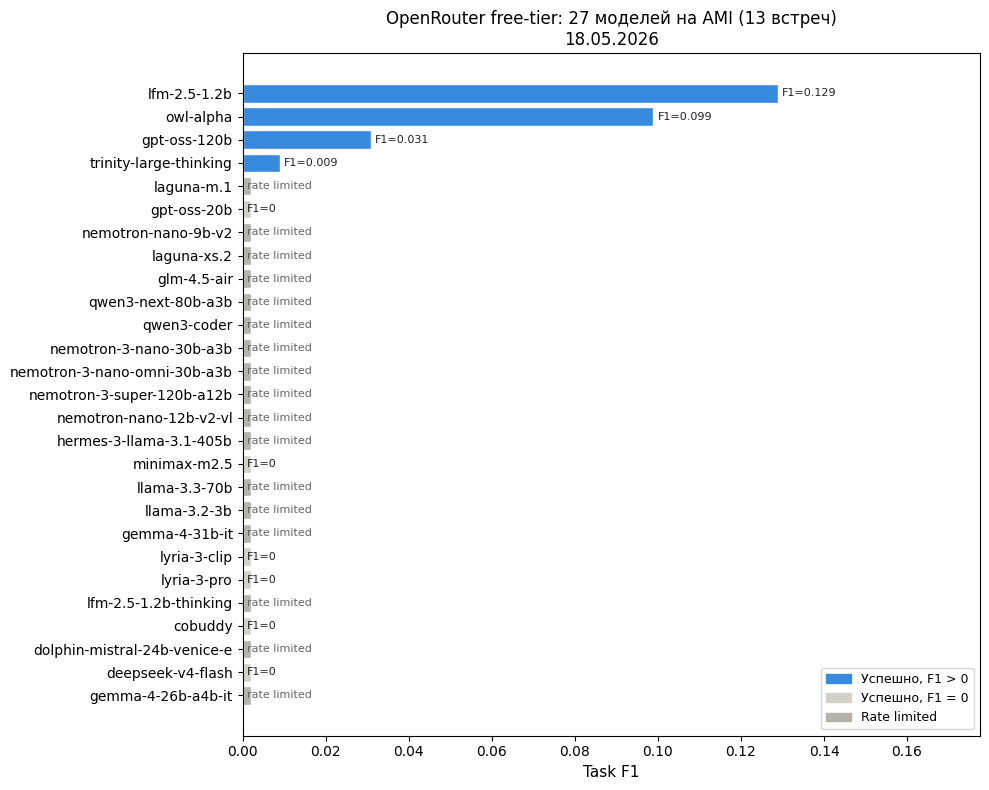

Сохранено: artifacts/openrouter_free_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Объединяем: успешные с реальным F1, rate-limited — с нулём для отображения
plot_df = free_df.copy()
f1_col  = 'avg_f1'  if 'avg_f1'  in plot_df.columns else 'avg_task_f1'
plot_df['f1_val']   = pd.to_numeric(plot_df[f1_col], errors='coerce').fillna(0)
plot_df['is_rl']    = plot_df['status'] == 'rate_limited'
plot_df = plot_df.sort_values('f1_val', ascending=True)

colors = ['#B4B2A9' if rl else ('#378ADD' if f1 > 0 else '#D3D1C7')
          for rl, f1 in zip(plot_df['is_rl'], plot_df['f1_val'])]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['short'], plot_df['f1_val'].clip(lower=0.002), color=colors, edgecolor='white')

ax.set_xlabel('Task F1', fontsize=11)
ax.set_title('OpenRouter free-tier: 27 моделей на AMI (13 встреч)\n18.05.2026', fontsize=12)
ax.set_xlim(0, plot_df['f1_val'].max() * 1.3 + 0.01)

# Аннотации
for i, (_, row) in enumerate(plot_df.iterrows()):
    label = 'rate limited' if row['is_rl'] else (f"F1={row['f1_val']:.3f}" if row['f1_val'] > 0 else 'F1=0')
    ax.text(row['f1_val'] + 0.001, i, label, va='center', fontsize=8,
            color='#666' if row['is_rl'] else '#222')

legend = [
    mpatches.Patch(color='#378ADD', label='Успешно, F1 > 0'),
    mpatches.Patch(color='#D3D1C7', label='Успешно, F1 = 0'),
    mpatches.Patch(color='#B4B2A9', label='Rate limited'),
]
ax.legend(handles=legend, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../artifacts/openrouter_free_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Сохранено: artifacts/openrouter_free_comparison.png')


### Выводы по free-tier бенчмарку

| Статус | Моделей |
|---|---:|
| Rate limited (недоступны) | 14 из 27 |
| Успешно, F1 > 0 | 3 |
| Успешно, F1 = 0 | 10 |

Лучшие из прошедших все 13 встреч:
- **`openrouter/owl-alpha`** — F1=0.099, 13/13, latency 11.3 с
- **`openai/gpt-oss-120b:free`** — F1=0.031, 13/13, latency 7.0 с

`liquid/lfm-2.5-1.2b-instruct:free` показал лучший F1=0.129, но завершил только 5/13 встреч из-за rate limit.

**Главный вывод**: free-tier OpenRouter в мае 2026 года непригоден для production —  
больше половины моделей недоступны, остальные дают F1 ниже rule-based baseline (0.14).  
Production-сервис использует **`google/gemini-2.5-flash-lite`** на платном тарифе.
